# Part 2 — FINDHasher_optimized vs dHash: Comprehensive Comparison

This notebook provides a full valuation of `FINDHasher_optimized` against `dHash` across three axes:

1. **Accuracy** — distance distributions, ROC/AUC, PR/AUC, EER, Precision/Recall/F1
2. **Robustness to transformations** 
3. **Computational cost** — wall-clock and CPU time per image, peak memory per image and scaling behaviour 


---
## 0. Setup

In [ ]:
import sys
import io
import timeit
import tracemalloc
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imagehash
from PIL import Image, ImageFilter, ImageEnhance
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

sys.path.insert(0, str(Path('../').resolve()))
from FINd_optimized import FINDHasher_optimized

random.seed(42)
np.random.seed(42)

find_hasher = FINDHasher_optimized()

def dhash_fn(img_path):
    """dHash hash_size=16 → 256-bit hash, matches FINd output size."""
    return imagehash.dhash(Image.open(img_path), hash_size=16)

def dhash_from_image(img):
    return imagehash.dhash(img, hash_size=16)

MEME_DIR   = Path('.../Hilary_term /DS in practice TA/Summative /meme_images') # Update this path to your local directory containing the meme images
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)
assert MEME_DIR.exists()

all_images = sorted(MEME_DIR.glob('*.jpg'))

family_map = defaultdict(list)
for p in all_images:
    family_map[p.name.split('_')[0]].append(p)

HASHERS = {'FINDHasher_optimized': find_hasher.fromFile, 'dHash': dhash_fn}
COLORS  = {'FINDHasher_optimized': 'steelblue', 'dHash': 'darkorange'}

print(f'Total images   : {len(all_images):,}')
print(f'Total families : {len(family_map):,}')
print(f'dHash bits     : {len(dhash_fn(all_images[0]).hash.flatten())}')
print('Setup complete.')


Total images   : 55,972
Total families : 1,035
dHash bits     : 256
Setup complete.


---
## 1. Accuracy Evaluation

### 1a — Build Evaluation Pairs

In [30]:
N_PAIRS = 500
random.seed(42)

eligible = [f for f, imgs in family_map.items() if len(imgs) >= 2]
fids     = list(family_map.keys())

same_pairs = []
while len(same_pairs) < N_PAIRS:
    fam = random.choice(eligible)
    p1, p2 = random.sample(family_map[fam], 2)
    same_pairs.append((p1, p2))

diff_pairs = []
while len(diff_pairs) < N_PAIRS:
    f1, f2 = random.sample(fids, 2)
    p1 = random.choice(family_map[f1])
    p2 = random.choice(family_map[f2])
    diff_pairs.append((p1, p2))

print(f'Same-family pairs     : {len(same_pairs)}')
print(f'Different-family pairs: {len(diff_pairs)}')


Same-family pairs     : 500
Different-family pairs: 500


### 1b — Compute Hamming Distances

In [31]:
print('Computing FINd distances...')
find_same  = [find_hasher.fromFile(str(p1)) - find_hasher.fromFile(str(p2)) for p1,p2 in same_pairs]
find_diff  = [find_hasher.fromFile(str(p1)) - find_hasher.fromFile(str(p2)) for p1,p2 in diff_pairs]

print('Computing dHash distances...')
dhash_same = [dhash_fn(p1) - dhash_fn(p2) for p1,p2 in same_pairs]
dhash_diff = [dhash_fn(p1) - dhash_fn(p2) for p1,p2 in diff_pairs]

print('\nFINd  | same mean: {:.1f}  diff mean: {:.1f}'.format(np.mean(find_same), np.mean(find_diff)))
print('dHash | same mean: {:.1f}  diff mean: {:.1f}'.format(np.mean(dhash_same), np.mean(dhash_diff)))


Computing FINd distances...
Computing dHash distances...

FINd  | same mean: 53.4  diff mean: 127.1
dHash | same mean: 40.1  diff mean: 127.0


### 1c — Hamming Distance Distributions

/var/folders/j_/2r5hsbjx0dj5684gmxzqz9jm0000gn/T/ipykernel_50051/2042525467.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([s_d, d_d], patch_artist=True,
/var/folders/j_/2r5hsbjx0dj5684gmxzqz9jm0000gn/T/ipykernel_50051/2042525467.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([s_d, d_d], patch_artist=True,


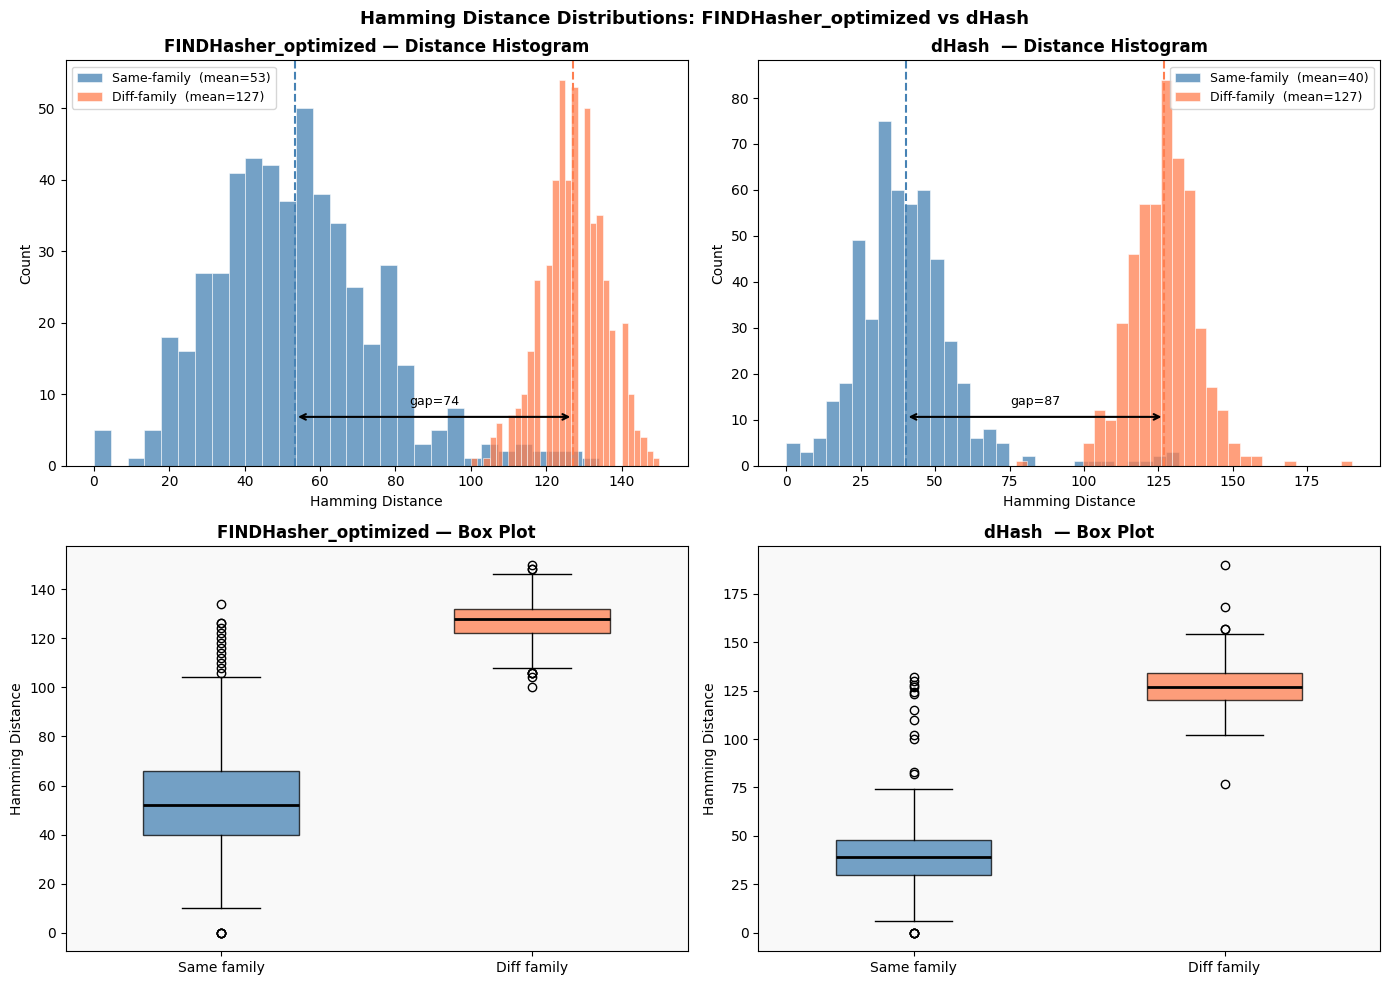

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (name, s_d, d_d) in enumerate([
    ('FINDHasher_optimized', find_same, find_diff),
    ('dHash ',        dhash_same, dhash_diff),
]):
    s_mean, d_mean = np.mean(s_d), np.mean(d_d)

    # Histogram
    ax = axes[0, col]
    ax.hist(s_d, bins=30, alpha=0.75, color='steelblue', edgecolor='white', lw=0.5,
            label=f'Same-family  (mean={s_mean:.0f})')
    ax.hist(d_d, bins=30, alpha=0.75, color='coral',     edgecolor='white', lw=0.5,
            label=f'Diff-family  (mean={d_mean:.0f})')
    ax.axvline(s_mean, color='steelblue', ls='--', lw=1.5)
    ax.axvline(d_mean, color='coral',     ls='--', lw=1.5)
    y_top = ax.get_ylim()[1]
    ax.annotate('', xy=(d_mean, y_top*0.12), xytext=(s_mean, y_top*0.12),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text((s_mean+d_mean)/2, y_top*0.15, f'gap={d_mean-s_mean:.0f}',
            ha='center', fontsize=9)
    ax.set_title(f'{name} — Distance Histogram', fontweight='bold')
    ax.set_xlabel('Hamming Distance')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

    # Box plot
    ax2 = axes[1, col]
    bp = ax2.boxplot([s_d, d_d], patch_artist=True,
                     labels=['Same family', 'Diff family'],
                     widths=0.5, medianprops=dict(color='black', lw=2))
    for patch, c in zip(bp['boxes'], ['steelblue', 'coral']):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax2.set_ylabel('Hamming Distance')
    ax2.set_title(f'{name} — Box Plot', fontweight='bold')
    ax2.set_facecolor('#f9f9f9')

fig.suptitle('Hamming Distance Distributions: FINDHasher_optimized vs dHash',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 1d — ROC Curve and AUC

A *positive* prediction is `distance < threshold`. I use `256 − distance` as the similarity score so that higher scores correspond to more likely duplicates, matching the sklearn convention.


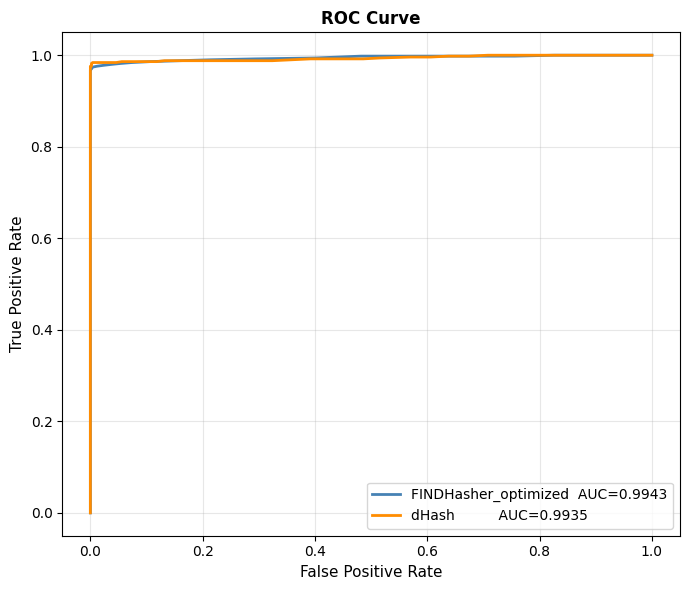

FINd AUC  : 0.9943
dHash AUC : 0.9935


In [33]:
labels = np.array([1]*N_PAIRS + [0]*N_PAIRS)

find_scores  = np.array([256-d for d in find_same]  + [256-d for d in find_diff])
dhash_scores = np.array([256-d for d in dhash_same] + [256-d for d in dhash_diff])

find_fpr,  find_tpr,  _  = roc_curve(labels, find_scores)
dhash_fpr, dhash_tpr, _  = roc_curve(labels, dhash_scores)
find_auc  = roc_auc_score(labels, find_scores)
dhash_auc = roc_auc_score(labels, dhash_scores)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(find_fpr,  find_tpr,  color='steelblue',  lw=2, label=f'FINDHasher_optimized  AUC={find_auc:.4f}')
ax.plot(dhash_fpr, dhash_tpr, color='darkorange', lw=2, label=f'dHash          AUC={dhash_auc:.4f}')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'FINd AUC  : {find_auc:.4f}')
print(f'dHash AUC : {dhash_auc:.4f}')


### 1e — Precision-Recall Curve and PR-AUC

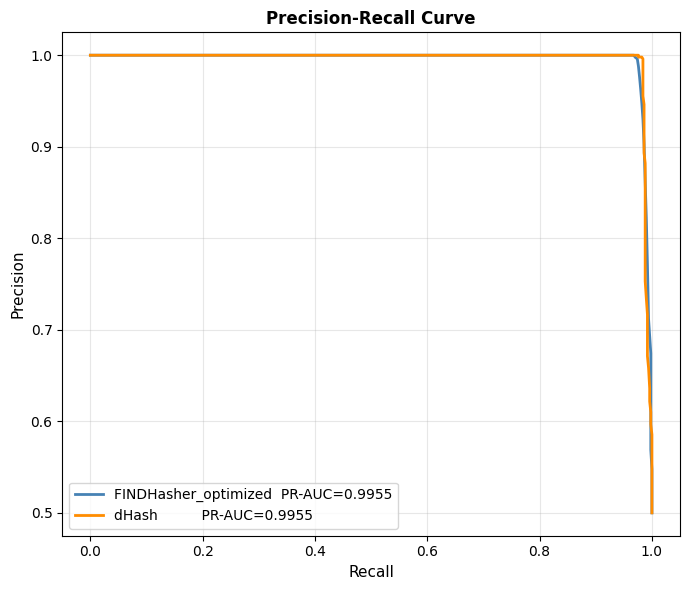

FINd PR-AUC  : 0.9955
dHash PR-AUC : 0.9955


In [34]:
find_p_curve,  find_r_curve,  _ = precision_recall_curve(labels, find_scores)
dhash_p_curve, dhash_r_curve, _ = precision_recall_curve(labels, dhash_scores)
find_pr_auc  = average_precision_score(labels, find_scores)
dhash_pr_auc = average_precision_score(labels, dhash_scores)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(find_r_curve,  find_p_curve,  color='steelblue',  lw=2, label=f'FINDHasher_optimized  PR-AUC={find_pr_auc:.4f}')
ax.plot(dhash_r_curve, dhash_p_curve, color='darkorange', lw=2, label=f'dHash          PR-AUC={dhash_pr_auc:.4f}')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'FINd PR-AUC  : {find_pr_auc:.4f}')
print(f'dHash PR-AUC : {dhash_pr_auc:.4f}')


### 1f — Precision, Recall, F1 Threshold Sweep

/var/folders/j_/2r5hsbjx0dj5684gmxzqz9jm0000gn/T/ipykernel_50051/1356335417.py:7: RuntimeWarning: invalid value encountered in divide
  p  = np.where(tp+fp > 0, tp/(tp+fp), 0.0)
/var/folders/j_/2r5hsbjx0dj5684gmxzqz9jm0000gn/T/ipykernel_50051/1356335417.py:9: RuntimeWarning: invalid value encountered in divide
  f1 = np.where(p+r > 0, 2*p*r/(p+r), 0.0)


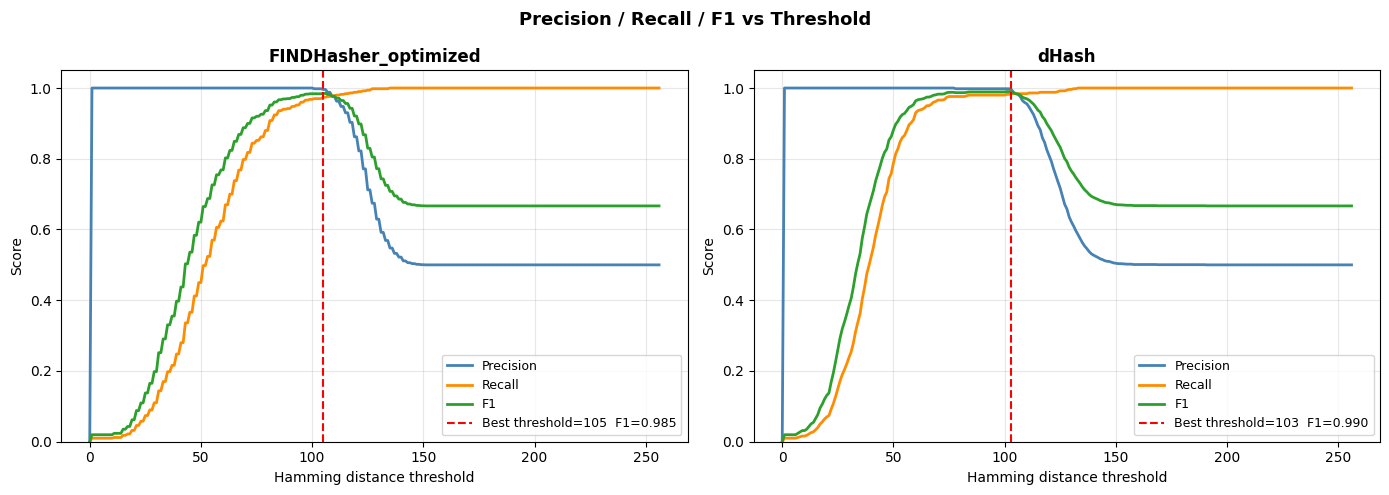

FINd  best thr=105   P=0.996  R=0.974  F1=0.985
dHash best thr=103  P=0.996  R=0.984  F1=0.990


In [37]:
def prf1_sweep(same_dists, diff_dists):
    thresholds = np.arange(0, 257)
    s, d = np.array(same_dists), np.array(diff_dists)
    tp = np.array([(s < t).sum() for t in thresholds], dtype=float)
    fp = np.array([(d < t).sum() for t in thresholds], dtype=float)
    fn = np.array([(s >= t).sum() for t in thresholds], dtype=float)
    p  = np.where(tp+fp > 0, tp/(tp+fp), 0.0)
    r  = np.where(tp+fn > 0, tp/(tp+fn), 0.0)
    f1 = np.where(p+r > 0, 2*p*r/(p+r), 0.0)
    return thresholds, p, r, f1

find_thr,  find_p,  find_r,  find_f1  = prf1_sweep(find_same,  find_diff)
dhash_thr, dhash_p, dhash_r, dhash_f1 = prf1_sweep(dhash_same, dhash_diff)
find_best  = np.argmax(find_f1)
dhash_best = np.argmax(dhash_f1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name, thr, p, r, f1, best in [
    (axes[0], 'FINDHasher_optimized', find_thr,  find_p,  find_r,  find_f1,  find_best),
    (axes[1], 'dHash',        dhash_thr, dhash_p, dhash_r, dhash_f1, dhash_best),
]:
    ax.plot(thr, p,  color='steelblue',  lw=2, label='Precision')
    ax.plot(thr, r,  color='darkorange', lw=2, label='Recall')
    ax.plot(thr, f1, color='#2ca02c',    lw=2, label='F1')
    ax.axvline(thr[best], color='red', ls='--', lw=1.5,
               label=f'Best threshold={thr[best]}  F1={f1[best]:.3f}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Hamming distance threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Precision / Recall / F1 vs Threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_prf1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'FINd  best thr={find_thr[find_best]}   P={find_p[find_best]:.3f}  R={find_r[find_best]:.3f}  F1={find_f1[find_best]:.3f}')
print(f'dHash best thr={dhash_thr[dhash_best]}  P={dhash_p[dhash_best]:.3f}  R={dhash_r[dhash_best]:.3f}  F1={dhash_f1[dhash_best]:.3f}')



# 2.Robustness to Image Transformations

To evaluate the algorithms' robustness for images transformations, I apply the same transformation suite as in the FINd evaluation (Notebook 01) to 10 randomly sampled images and compare mean Hamming distances for both algorthms.


In [38]:
def apply_transforms(img_path):
    img = Image.open(img_path).convert('RGB')
    t = {}
    for q in [90, 70, 50, 30]:
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=q); buf.seek(0)
        t[f'JPEG q={q}'] = Image.open(buf).convert('RGB')
    w, h = img.size
    for scale, label in [(0.75, 'Resize 75%'), (0.5, 'Resize 50%')]:
        t[label] = img.resize((int(w*scale), int(h*scale)), Image.LANCZOS)
    t['Brightness 50%']  = ImageEnhance.Brightness(img).enhance(0.5)
    t['Brightness 150%'] = ImageEnhance.Brightness(img).enhance(1.5)
    t['Gaussian blur']   = img.filter(ImageFilter.GaussianBlur(radius=2))
    return img, t

rob_images = random.sample(all_images, 10)
rob_records = []
for img_path in rob_images:
    orig_img, transforms = apply_transforms(img_path)
    h_find_orig  = find_hasher.fromImage(orig_img)
    h_dhash_orig = dhash_from_image(orig_img)
    for t_name, t_img in transforms.items():
        rob_records.append({
            'transformation': t_name,
            'find_dist':  find_hasher.fromImage(t_img) - h_find_orig,
            'dhash_dist': dhash_from_image(t_img) - h_dhash_orig,
        })

rob_df  = pd.DataFrame(rob_records)
rob_sum = rob_df.groupby('transformation').agg(
    FINd_mean=('find_dist', 'mean'),
    dHash_mean=('dhash_dist', 'mean')
).round(2).sort_values('FINd_mean')
print(rob_sum.to_string())


                 FINd_mean  dHash_mean
transformation                        
JPEG q=90              0.0         0.9
Brightness 50%         0.2        11.1
JPEG q=70              0.6         3.0
JPEG q=50              1.2         3.4
JPEG q=30              1.8         4.1
Gaussian blur          6.2         5.5
Resize 75%             8.8         2.1
Resize 50%            10.0         3.3
Brightness 150%       17.2        15.9


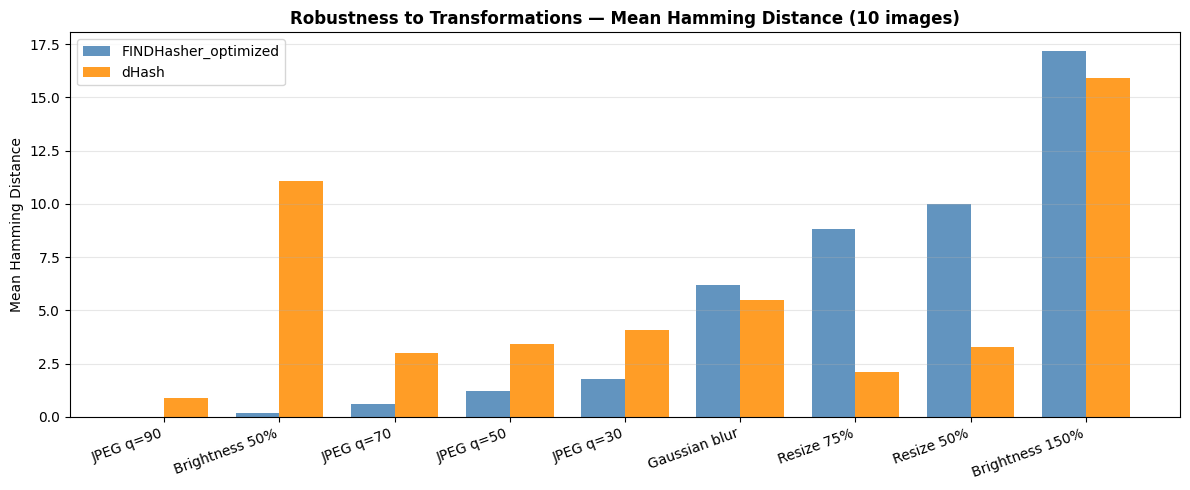

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))
x   = np.arange(len(rob_sum))
w   = 0.38
ax.bar(x - w/2, rob_sum['FINd_mean'],  width=w, color='steelblue',  label='FINDHasher_optimized', alpha=0.85)
ax.bar(x + w/2, rob_sum['dHash_mean'], width=w, color='darkorange', label='dHash',          alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(rob_sum.index, rotation=20, ha='right')
ax.set_ylabel('Mean Hamming Distance')
ax.set_title('Robustness to Transformations — Mean Hamming Distance (10 images)',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_robustness.png', dpi=150, bbox_inches='tight')
plt.show()


Summary

---
## 3. Runtime Comparison

Wall-clock (`timeit.repeat`, min of 10 repeats) and CPU time (`time.process_time`) on 50 images.

In [43]:
BENCH = random.sample(all_images, 50)
REPS  = 10

# Wall-clock
find_wall  = timeit.repeat(
    stmt='[find_hasher.fromFile(str(p)) for p in BENCH]',
    globals={'find_hasher': find_hasher, 'BENCH': BENCH}, repeat=REPS, number=1)
dhash_wall = timeit.repeat(
    stmt='[dhash_fn(p) for p in BENCH]',
    globals={'dhash_fn': dhash_fn, 'BENCH': BENCH}, repeat=REPS, number=1)

find_ms  = [(t/len(BENCH))*1000 for t in find_wall]
dhash_ms = [(t/len(BENCH))*1000 for t in dhash_wall]

# CPU time
def cpu_time_per_img(fn, imgs, reps=5):
    times = []
    for _ in range(reps):
        t0 = time.process_time()
        for p in imgs: fn(str(p))
        times.append((time.process_time() - t0) / len(imgs) * 1000)
    return times

find_cpu  = cpu_time_per_img(find_hasher.fromFile, BENCH[:20])
dhash_cpu = cpu_time_per_img(dhash_fn, BENCH[:20])

print(f'FINd  wall-clock : {np.mean(find_ms):.2f} ± {np.std(find_ms):.2f} ms/image')
print(f'dHash wall-clock : {np.mean(dhash_ms):.2f} ± {np.std(dhash_ms):.2f} ms/image')
print(f'FINd  CPU time   : {np.mean(find_cpu):.2f} ± {np.std(find_cpu):.2f} ms/image')
print(f'dHash CPU time   : {np.mean(dhash_cpu):.2f} ± {np.std(dhash_cpu):.2f} ms/image')


FINd  wall-clock : 11.75 ± 0.68 ms/image
dHash wall-clock : 0.23 ± 0.01 ms/image
FINd  CPU time   : 10.66 ± 0.15 ms/image
dHash CPU time   : 0.22 ± 0.01 ms/image


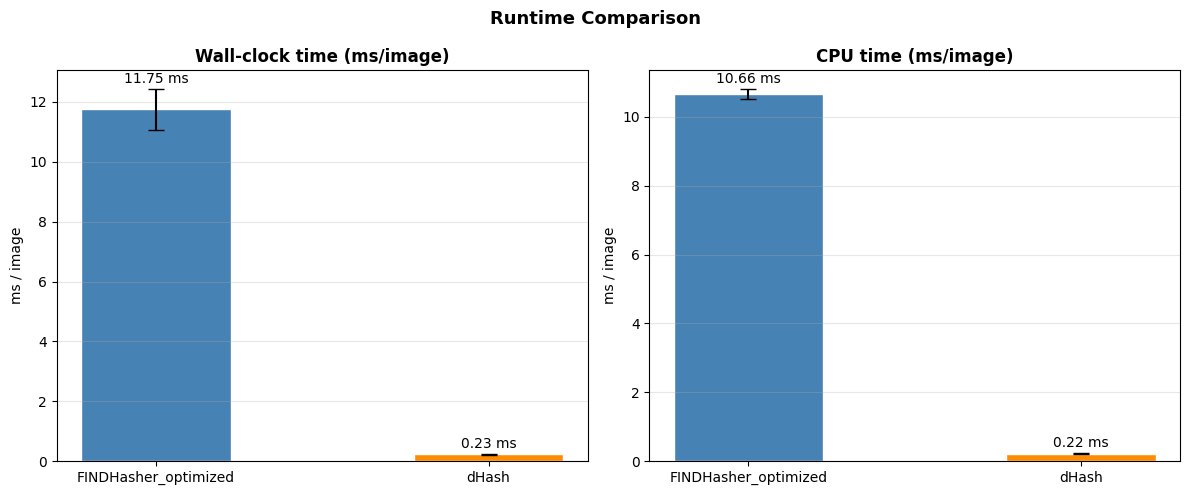

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, find_d, dhash_d in [
    (axes[0], 'Wall-clock time (ms/image)', find_ms,  dhash_ms),
    (axes[1], 'CPU time (ms/image)',         find_cpu, dhash_cpu),
]:
    means = [np.mean(find_d), np.mean(dhash_d)]
    stds  = [np.std(find_d),  np.std(dhash_d)]
    bars  = ax.bar(['FINDHasher_optimized', 'dHash'],
                   means, color=['steelblue', 'darkorange'],
                   width=0.45, yerr=stds, capsize=6, edgecolor='white')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, m+s+0.1,
                f'{m:.2f} ms', ha='center', va='bottom', fontsize=10)
    ax.set_ylabel('ms / image')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Runtime Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_runtime.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Memory Comparison

Peak memory per image using `tracemalloc` (5 repetitions).

In [44]:
TEST_IMG = str(BENCH[0])

find_peaks, dhash_peaks = [], []
for _ in range(5):
    tracemalloc.start()
    find_hasher.fromFile(TEST_IMG)
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    find_peaks.append(peak / 1024)

    tracemalloc.start()
    dhash_fn(TEST_IMG)
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    dhash_peaks.append(peak / 1024)

print(f'FINd  peak memory : {np.mean(find_peaks):.0f} KB')
print(f'dHash peak memory : {np.mean(dhash_peaks):.0f} KB')


FINd  peak memory : 8856 KB
dHash peak memory : 71 KB


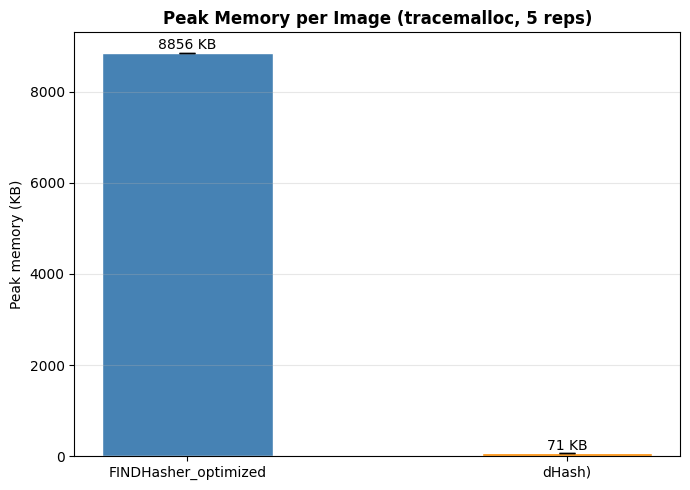

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))
means = [np.mean(find_peaks), np.mean(dhash_peaks)]
stds  = [np.std(find_peaks),  np.std(dhash_peaks)]
bars  = ax.bar(['FINDHasher_optimized', 'dHash)'],
               means, color=['steelblue', 'darkorange'],
               width=0.45, yerr=stds, capsize=6, edgecolor='white')
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m+s+5,
            f'{m:.0f} KB', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Peak memory (KB)')
ax.set_title('Peak Memory per Image (tracemalloc, 5 reps)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_memory.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Scaling Analysis

Total wall-clock runtime and peak memory across dataset sizes N = 10, 50, 100, 500.

In [46]:
SIZES = [10, 50, 100, 500]
scaling = []
for n in SIZES:
    sample = random.sample(all_images, n)
    # FINd
    t0 = time.time()
    for p in sample: find_hasher.fromFile(str(p))
    find_t = time.time() - t0
    # dHash
    t0 = time.time()
    for p in sample: dhash_fn(p)
    dhash_t = time.time() - t0
    scaling.append({'N': n, 'find_total_s': find_t, 'dhash_total_s': dhash_t,
                    'find_per_img_ms': find_t/n*1000, 'dhash_per_img_ms': dhash_t/n*1000})
    print(f'N={n:4d} | FINd {find_t:.2f}s ({find_t/n*1000:.1f}ms/img)  '
          f'dHash {dhash_t:.2f}s ({dhash_t/n*1000:.1f}ms/img)')

scale_df = pd.DataFrame(scaling)
display(scale_df.round(3))


N=  10 | FINd 0.14s (13.5ms/img)  dHash 0.00s (0.3ms/img)
N=  50 | FINd 0.58s (11.7ms/img)  dHash 0.02s (0.3ms/img)
N= 100 | FINd 1.22s (12.2ms/img)  dHash 0.06s (0.6ms/img)
N= 500 | FINd 5.99s (12.0ms/img)  dHash 0.13s (0.3ms/img)


,N,find_total_s,dhash_total_s,find_per_img_ms,dhash_per_img_ms
0,10,0.135,0.003,13.526,0.291
1,50,0.583,0.016,11.659,0.319
2,100,1.223,0.057,12.234,0.572
3,500,5.988,0.129,11.976,0.258


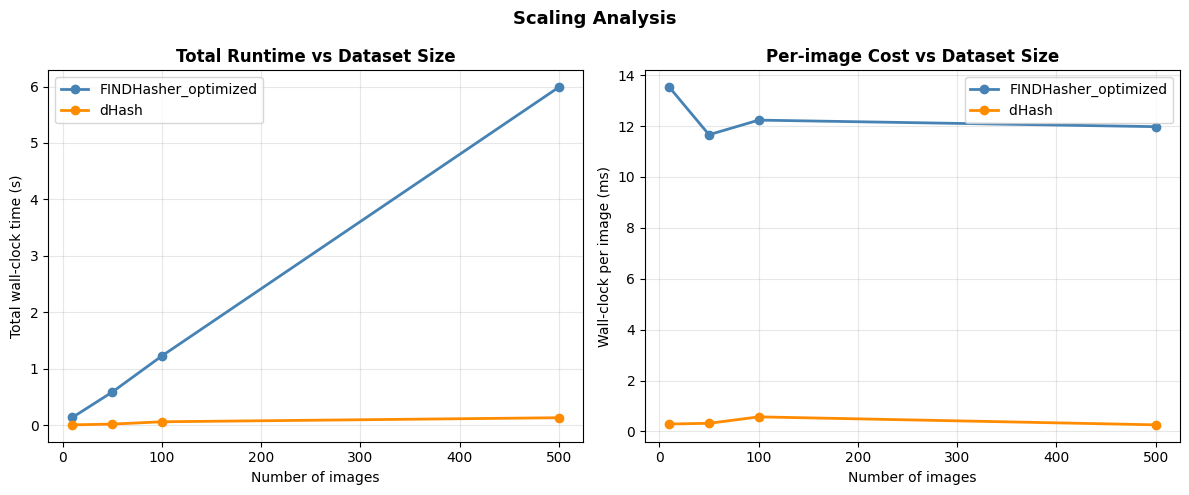

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
Ns = scale_df['N']

axes[0].plot(Ns, scale_df['find_total_s'],  'o-', color='steelblue',  lw=2, label='FINDHasher_optimized')
axes[0].plot(Ns, scale_df['dhash_total_s'], 'o-', color='darkorange', lw=2, label='dHash')
axes[0].set_xlabel('Number of images')
axes[0].set_ylabel('Total wall-clock time (s)')
axes[0].set_title('Total Runtime vs Dataset Size', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(Ns, scale_df['find_per_img_ms'],  'o-', color='steelblue',  lw=2, label='FINDHasher_optimized')
axes[1].plot(Ns, scale_df['dhash_per_img_ms'], 'o-', color='darkorange', lw=2, label='dHash ')
axes[1].set_xlabel('Number of images')
axes[1].set_ylabel('Wall-clock per image (ms)')
axes[1].set_title('Per-image Cost vs Dataset Size', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Scaling Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_scaling.png', dpi=150, bbox_inches='tight')
plt.show()


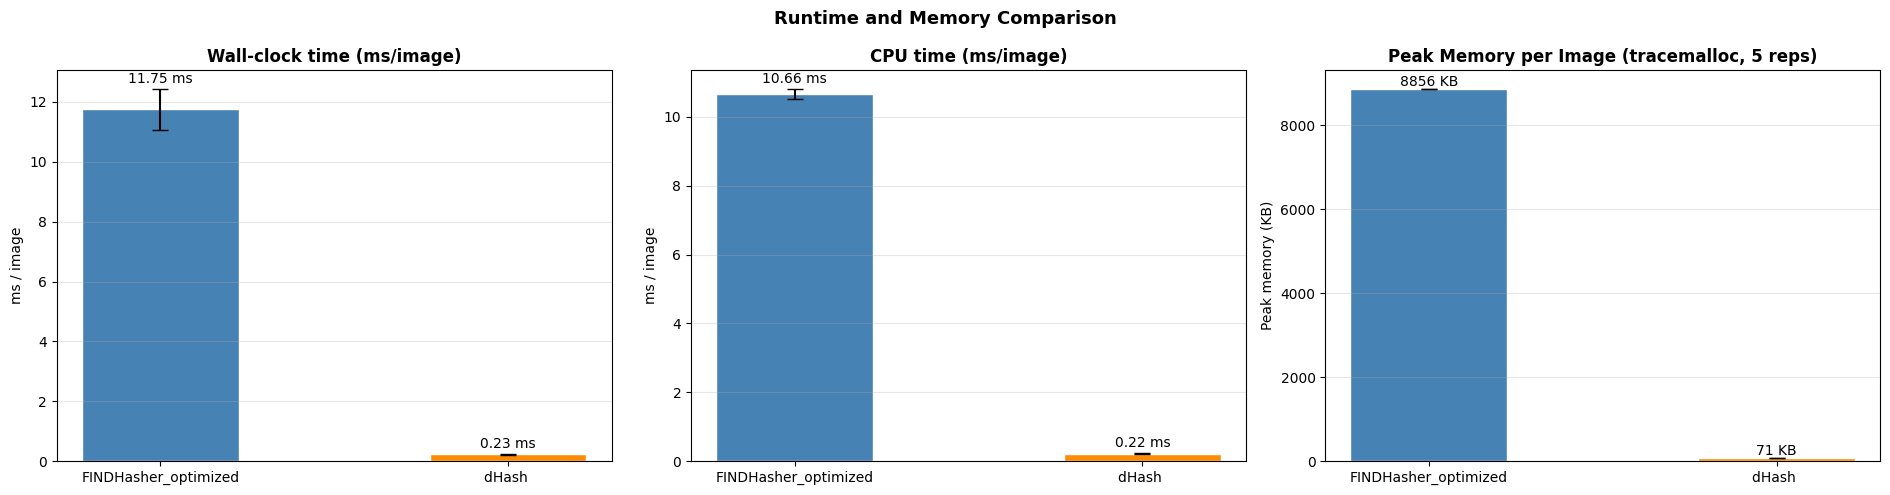

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# --- Wall-clock ---
means_w = [np.mean(find_ms), np.mean(dhash_ms)]
stds_w  = [np.std(find_ms),  np.std(dhash_ms)]
bars = axes[0].bar(['FINDHasher_optimized', 'dHash '],
                   means_w, color=['steelblue', 'darkorange'],
                   width=0.45, yerr=stds_w, capsize=6, edgecolor='white')
for bar, m, s in zip(bars, means_w, stds_w):
    axes[0].text(bar.get_x() + bar.get_width()/2, m+s+0.1,
                 f'{m:.2f} ms', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('ms / image')
axes[0].set_title('Wall-clock time (ms/image)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# --- CPU time ---
means_c = [np.mean(find_cpu), np.mean(dhash_cpu)]
stds_c  = [np.std(find_cpu),  np.std(dhash_cpu)]
bars = axes[1].bar(['FINDHasher_optimized', 'dHash '],
                   means_c, color=['steelblue', 'darkorange'],
                   width=0.45, yerr=stds_c, capsize=6, edgecolor='white')
for bar, m, s in zip(bars, means_c, stds_c):
    axes[1].text(bar.get_x() + bar.get_width()/2, m+s+0.1,
                 f'{m:.2f} ms', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('ms / image')
axes[1].set_title('CPU time (ms/image)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# --- Peak memory ---
means_m = [np.mean(find_peaks), np.mean(dhash_peaks)]
stds_m  = [np.std(find_peaks),  np.std(dhash_peaks)]
bars = axes[2].bar(['FINDHasher_optimized', 'dHash '],
                   means_m, color=['steelblue', 'darkorange'],
                   width=0.45, yerr=stds_m, capsize=6, edgecolor='white')
for bar, m, s in zip(bars, means_m, stds_m):
    axes[2].text(bar.get_x() + bar.get_width()/2, m+s+5,
                 f'{m:.0f} KB', ha='center', va='bottom', fontsize=10)
axes[2].set_ylabel('Peak memory (KB)')
axes[2].set_title('Peak Memory per Image (tracemalloc, 5 reps)', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Runtime and Memory Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_runtime_memory.png', dpi=150, bbox_inches='tight')
plt.show()
